In [7]:
import pandas as pd

df_1 = pd.read_csv("data/raw_data/December_comments.csv")
df_2 = pd.read_csv("data/raw_data/January_comments.csv")
df_3 = pd.read_csv("data/raw_data/February_comments.csv")
df_4 = pd.read_csv("data/raw_data/March_comments.csv")
df_5 = pd.read_csv("data/raw_data/April_comments.csv")


Combined_df = pd.concat([df_1, df_2, df_3, df_4, df_5], ignore_index=True)

Combined_df['Date'] = pd.to_datetime(Combined_df['Date'], errors='coerce')

Combined_df.to_csv("data/cleaned_data/Combined_Comments.csv", index=False)

print("成功合并为 Combined_Comments.csv")

成功合并为 Combined_Comments.csv


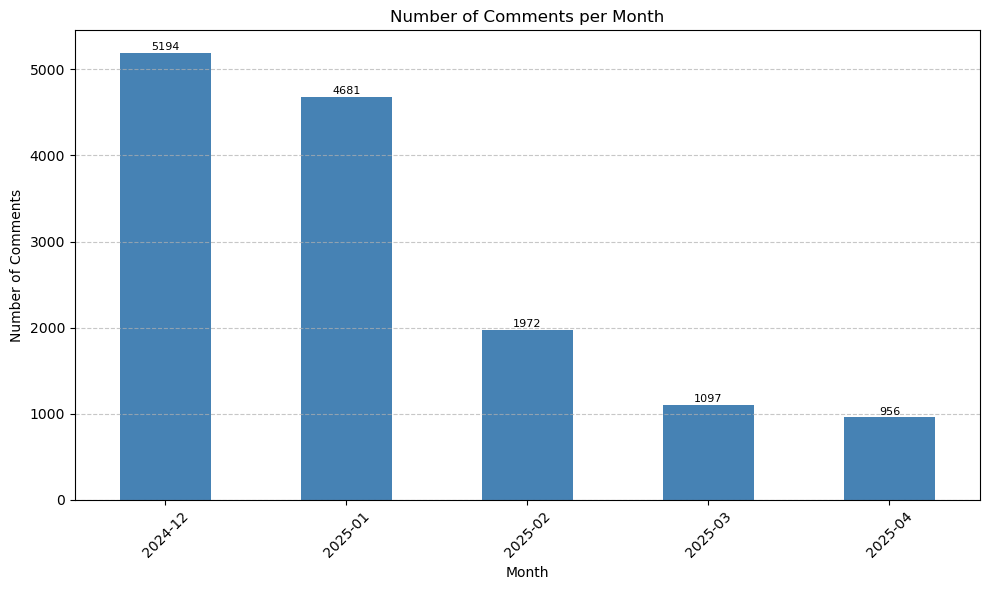

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/cleaned_data/Combined_comments.csv")

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])

df['Year-Month'] = df['Date'].dt.strftime('%Y-%m')

monthly_counts = df['Year-Month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
ax = monthly_counts.plot(kind='bar', color='steelblue')
plt.title("Number of Comments per Month")
plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(monthly_counts):
    ax.text(i, value + 10, str(value), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()